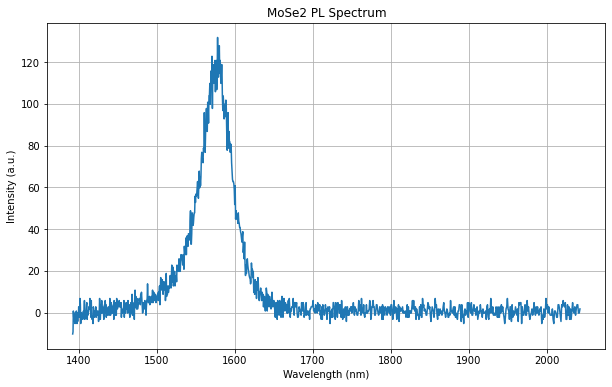

In [6]:
df.columns=['wavelength', 'intensity']

plt.figure(figsize=(10,6))
plt.plot(df['wavelength'], df['intensity'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (a.u.)')
plt.title('MoSe2 PL Spectrum')
plt.grid(True)
plt.show()

In [22]:
from scipy.signal import savgol_filter, find_peaks
import numpy as np

df['smoothed'] = savgol_filter(df['intensity'], window_length=11, polyorder=3)
peaks,properties = find_peaks(df['smoothed'],height=50, prominence=20)
peak_wavelengths = df['wavelength'].iloc[peaks].values
peak_intensities = df['smoothed'].iloc[peaks].values

print(f"detected peaks: {len(peaks)}")
for i, (w, i_val) in enumerate(zip(peak_wavelengths, peak_intensities)):
        print(f"peak {i+1}: {w: .2f} nm, intensity : {i_val:.2f}")

detected peaks: 1
peak 1:  1579.56 nm, intensity : 120.35


In [28]:
peak_idx = peaks[0]
peak_val= df['smoothed'].iloc[peak_idx]
half_max = peak_val / 2
left_side = df['smoothed'].iloc[:peak_idx]
right_side = df['smoothed'].iloc[peak_idx:]

left_idx = (left_side - half_max).abs().idxmin()
right_idx= (right_side - half_max).abs().idxmin()

left_wl = df['wavelength'].iloc[left_idx]
right_wl = df['wavelength'].iloc[right_idx]

fwhm = abs(right_wl - left_wl)

print(f"peak position : {df['wavelength'].iloc[peak_idx]:.2f} nm")
print(f"peak intensity : {peak_val:.2f}")
print(f"Half maxium : {half_max:.2f}")
print(f"FWHM : {fwhm:.2f} nm")

peak position : 1579.56 nm
peak intensity : 120.35
Half maxium : 60.17
FWHM : 44.34 nm
